### Analysis of learned plasticity rule that organizes integrating network
Networks initialized with structured input weights, but weights in 'ellipsoid body' are random but fully connected.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import glob as glob
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
import os
from aux import zero_pad, format_plot, format_pc_plot, add_inset_axes
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.offline as pyo
import subprocess
import cv2
from natsort import natsorted
import seaborn as sns

CELL_TYPE_1_SIZE = 2

plt.rcParams['font.family'] = 'Helvetica'

DATA_PATHS_NO_HET_SHORT = [
    '2D_short_reverted_test_000850_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:56:02.567091_run_None',
    '2D_short_reverted_test_000851_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:56:02.567095_run_None',
    '2D_short_reverted_test_000852_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:56:02.567326_run_None',
    '2D_short_reverted_test_000854_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:55:49.971242_run_None',
    '2D_short_reverted_test_000855_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:56:06.935493_run_None',
    '2D_short_reverted_test_000856_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:56:06.935488_run_None',
    '2D_short_reverted_test_000857_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:55:51.875753_run_None',
    '2D_short_reverted_test_000858_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:55:51.915822_run_None',
]

DATA_PATHS_NO_HET_LONG = [
    '2D_long_reverted_test_000866_time_1.0_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-14_12:27:15.036861_run_None',
    '2D_long_reverted_test_000867_time_1.0_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-14_12:27:12.464502_run_None',
]

DATA_PATHS_HET_SHORT = [
    '2D_short_reverted_test_000755_time_0.3_inp_0.27_het_0.2_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_13:33:23.140584_run_None',
    '2D_short_reverted_test_000756_time_0.3_inp_0.27_het_0.2_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_13:33:19.544611_run_None',
    '2D_short_reverted_test_000758_time_0.3_inp_0.27_het_0.2_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_13:33:19.710490_run_None',
]

DATA_PATHS_HET_LONG = [
    '2D_long_reverted_test_000806_time_1.0_inp_0.27_het_0.2_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-14_12:41:29.302142_run_None',
    '2D_long_reverted_test_000808_time_1.0_inp_0.27_het_0.2_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-14_12:41:29.302142_run_None',
]

In [2]:
def load_numpy(data_path, last_n=None):
    file_names = glob.glob(data_path)
    data = []
    for file_name in sorted(file_names):
        data_for_file = np.load(file_name)
        data.append(data_for_file)
    if last_n is not None:
        data = data[-last_n:]
    data = np.stack(data)
    return data

def make_path_if_not_exists(path_str):
    Path(path_str).mkdir(parents=True, exist_ok=True)

def load_r_and_int_values(rule_path, net_path, last_n=100):
    all_r = np.stack(load_numpy(os.path.join(rule_path, 'activities', net_path), last_n=last_n)).squeeze()
    all_int_values = np.stack(load_numpy(os.path.join(rule_path, 'integrated_values', net_path), last_n=last_n)).squeeze()
    
    if last_n is not None:
        last_n_r = all_r[-last_n:, 200:, :CELL_TYPE_1_SIZE]
        all_int_values = all_int_values[-last_n:, :]
    else:
        last_n_r = all_r[:, 200:, :CELL_TYPE_1_SIZE]
        
    last_n_r = np.transpose(last_n_r, [2, 0, 1])

    return last_n_r, all_int_values

def load_targets_and_predictions(rule_path, net_path, last_n):
    predictions = np.stack(load_numpy(os.path.join(rule_path, 'predictions', net_path), last_n=last_n)).squeeze()
    targets = np.stack(load_numpy(os.path.join(rule_path, 'targets', net_path), last_n=last_n)).squeeze()

    return targets, predictions

### Analysis of weights

In [3]:
from matplotlib.colors import TwoSlopeNorm

def plot_step(run, v=6, save_name=None, mask=None, scale=3):
    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
    
    cmap = sns.diverging_palette(250, 10, s=100, l=55, as_cmap=True)

    # Use TwoSlopeNorm to ensure white maps to 0
    norm = TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)
    
    # Plot the matrix
    if mask is None:
        im = axs.matshow(all_w[run, ...], cmap=cmap, norm=norm)
    else:
        # print(all_w[run, ...][mask, :][:, mask])
        im = axs.matshow(all_w[run, ...][mask, :][:, mask], cmap=cmap, norm=norm)

    # Ticks and labels
    # axs.set_xticks([15, 30, 45])
    # axs.set_yticks([15, 30, 45])
    axs.tick_params(axis='both')
    axs.set_xlabel('Presynaptic')
    axs.set_ylabel('Postsynaptic')
    axs.xaxis.set_label_position('top')
    axs.tick_params(axis='x', bottom=False)
    axs.tick_params(axis='both', length=10)
    axs.spines['right'].set_visible(False)
    axs.spines['bottom'].set_visible(False)

    x = np.arange(CELL_TYPE_1_SIZE + 1)
    axs.set_xticks(x, x+1)
    axs.set_yticks(x, x+1)

    # Add colorbar
    cbar = fig.colorbar(im, ax=axs, fraction=0.46, pad=0.04, aspect=10)
    # cbar.ax.tick_params(labelsize=14)
    cbar.set_label('Weight')


    format_plot(axs, topspine=True, rightspine=True)
    format_plot(cbar.ax)

    if save_name is not None:
        fig.savefig(save_name, bbox_inches='tight')

    return fig

In [145]:
# # Directory to save frames
# frames_dir = "./weight_evo"
# os.makedirs(frames_dir, exist_ok=True)

# # Parameters
# num_runs = 320
# timestep = 0

# # Generate and save plots as images
# for run in range(num_runs):
#     fig = plot_step(run)
#     fig.tight_layout()
#     frame_path = os.path.join(frames_dir, f"frame_{run:03}_{timestep:04}.png")
#     fig.tight_layout()
#     fig.savefig(frame_path)
#     plt.close(fig)  # Free memory

In [146]:
# # Parameters
# image_folder = './weight_evo'     # directory with images
# output_video = 'output.mp4'       # output filename
# fps = 30                          # frames per second

# # Get all .png files, sorted naturally
# images = [img for img in os.listdir(image_folder) if img.endswith(".png")]
# images = natsorted(images)  # natural sort: img1, img2, ..., img10

# # Read first image to get dimensions
# first_frame = cv2.imread(os.path.join(image_folder, images[0]))
# height, width, layers = first_frame.shape

# # Define the video writer
# fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # or 'XVID' for .avi
# video = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

# # Add frames
# for image in images:
#     frame = cv2.imread(os.path.join(image_folder, image))
#     video.write(frame)

# video.release()
# print("Video written to", output_video)

2D_short_reverted_test_000850_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:56:02.567091_run_None
2D_short_reverted_test_000851_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:56:02.567095_run_None
2D_short_reverted_test_000852_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:56:02.567326_run_None
2D_short_reverted_test_000854_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:55:49.971242_run_None
2D_short_reverted_test_000855_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:56:06.935493_run_None
2D_short_reverted_test_000856_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:56:06.935488_run_Non

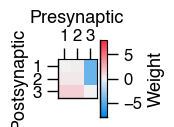

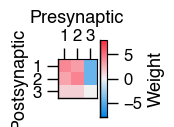

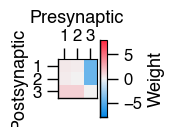

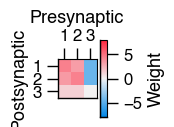

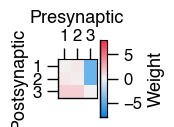

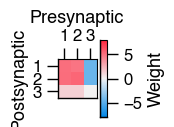

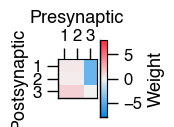

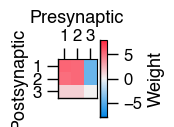

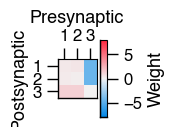

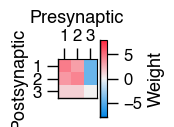

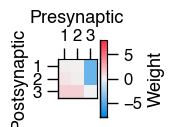

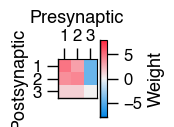

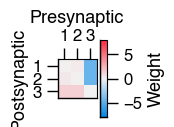

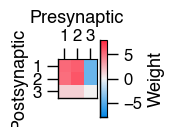

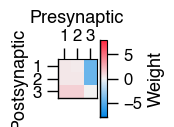

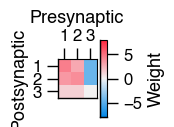

In [148]:
for i, dp in enumerate(DATA_PATHS_NO_HET_SHORT):
    print(dp)
    all_w = load_numpy(os.path.join('sims_out', dp, 'weights/net_005.npy')).squeeze(0)

    mask = np.array([1, 1, 0, 0, 0, 0, 1]).astype(bool)
    f = plot_step(0, save_name=f'./figures/2d_no_het_short_initial_weight_mat_{i}.svg', v=8, scale=1, mask=mask)
    f = plot_step(410, save_name=f'./figures/2d_no_het_short_final_weight_mat_{i}.svg', v=8, scale=1, mask=mask)

2D_long_reverted_test_000866_time_1.0_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_13:27:48.321997_run_None
2D_long_reverted_test_000867_time_1.0_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_13:27:48.295890_run_None


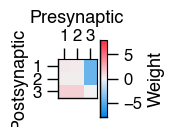

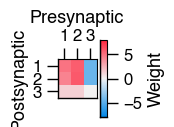

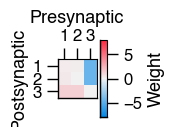

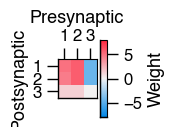

In [149]:
for i, dp in enumerate(DATA_PATHS_NO_HET_LONG):
    print(dp)
    all_w = load_numpy(os.path.join('sims_out', dp, 'weights/net_005.npy')).squeeze(0)

    mask = np.array([1, 1, 0, 0, 0, 0, 1]).astype(bool)
    f = plot_step(0, save_name=f'./figures/2d_no_het_long_initial_weight_mat_{i}.svg', v=8, scale=1, mask=mask)
    f = plot_step(410, save_name=f'./figures/2d_no_het_long_final_weight_mat_{i}.svg', v=8, scale=1, mask=mask)

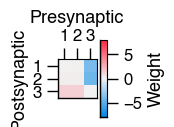

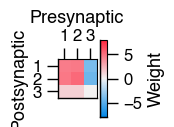

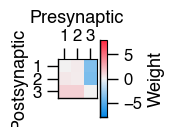

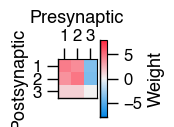

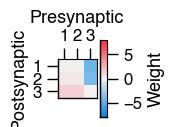

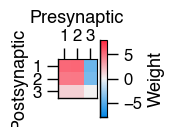

In [150]:
for i, dp in enumerate(DATA_PATHS_HET_SHORT):
    all_w = load_numpy(os.path.join('sims_out', dp, 'weights/net_005.npy')).squeeze(0)

    mask = np.array([1, 1, 0, 0, 0, 0, 1]).astype(bool)
    f = plot_step(0, save_name=f'./figures/2d_het_short_initial_weight_mat_{i}.svg', v=8, scale=1, mask=mask)
    f = plot_step(410, save_name=f'./figures/2d_het_short_final_weight_mat_{i}.svg', v=8, scale=1, mask=mask)

In [151]:
def plot_weight_trajectories_for_rule(dp, diag_offdiag_axs, diag_diag_axs, color, save_name=None):
    fig_w, axs_w = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(1.5, 1.5))
    fig_diff, axs_diff = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(1.5, 1.5))
    
    for i in range(3,4):
        all_w = load_numpy(os.path.join(dp, f'weights/net_00{i}.npy')).squeeze()

        print(all_w.shape)
    
        w11 = all_w[:, 0, 0]
        w12 = all_w[:, 0, 1]
        w22 = all_w[:, 1, 1]
        w21 = all_w[:, 1, 0]
    
        w_inh_1 = all_w[:, 0, -1]
        w_inh_2 = all_w[:, 1, -1]
    
        w11_adj = w11 + w_inh_1 * all_w[:, -1, 0]
        w12_adj = w12 + w_inh_1 * all_w[:, -1, 0]
        w22_adj = w22 + w_inh_2 * all_w[:, -1, 0]
        w21_adj = w21 + w_inh_2 * all_w[:, -1, 0]
    
        axs_diff.plot(np.arange(all_w.shape[0]), w11_adj - w21_adj, color=color, lw=1.5)
        axs_diff.plot(np.arange(all_w.shape[0]), w22_adj - w12_adj, color=color, lw=1.5, linestyle='--')
    
        axs_w.plot(np.arange(all_w.shape[0]), w11, color=color, lw=1.5)
        axs_w.plot(np.arange(all_w.shape[0]), w22, color=color, lw=1.5, ls='--')
        axs_w.plot(np.arange(all_w.shape[0]), w21, color=color, lw=1.5)
        axs_w.plot(np.arange(all_w.shape[0]), w12, color=color, lw=1.5, ls='--')
    
        diag_offdiag_axs.scatter(w21_adj[-10:].mean(), w11_adj[-10:].mean(), edgecolor=color, facecolor='none', s=50)
        diag_offdiag_axs.scatter(w12_adj[-10:].mean(), w22_adj[-10:].mean(), edgecolor=color, facecolor='none', s=50, marker='s')
    
        diag_diag_axs.scatter(w11_adj[-10:].mean(), w22_adj[-10:].mean(), edgecolor=color, facecolor='none', s=50)
    
    axs_w.set_xlabel('Epoch')
    axs_w.set_ylabel('Diagonal')
    axs_w.set_ylabel('Off-diagonal')

    axs_diff.axhline(1, color='grey', ls='--')
    axs_diff.set_ylabel(r'$w_{11}^* - w_{21}^*$')
    
    format_plot(axs_w)
    format_plot(axs_diff)


    if save_name is not None:
        # fig.savefig(save_name + 'offdiag_series.svg', bbox_inches='tight')
        fig_w.savefig(save_name + 'diags_and_offdiags_series.svg', bbox_inches='tight')
        fig_2.savefig(save_name + 'diag_minus_offdiag.svg', bbox_inches='tight')
        # fig_3.savefig(save_name + 'diags.svg', bbox_inches='tight')

In [152]:
def plot_all_weight_stats(dfs):
    colors = sns.color_palette('bright', 10)
    
    diag_offdiag_fig, diag_offdiag_axs = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(1.5, 1.5))
    diag_diag_fig, diag_diag_axs = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(1.5, 1.5))
    
    diag_offdiag_axs.set_ylabel(r'$w_{jj}^*$')
    diag_offdiag_axs.set_xlabel(r'$w_{ij}^*$')
    
    diag_diag_axs.set_xlabel(r'$w_{11}$')
    diag_diag_axs.set_ylabel(r'$w_{22}$')
    
        
    for i, dp in enumerate(dfs):
        
        plot_weight_trajectories_for_rule(os.path.join('sims_out', dp), diag_offdiag_axs, diag_diag_axs, color=colors[i])
    
    diag_offdiag_axs.plot([-3, 0], [-2, 1], zorder=-1, ls='--', color='gray', alpha=0.5)
    diag_diag_axs.plot([0, 2], [0, 2], zorder=-1, ls='--', color='gray', alpha=0.5)
    
    format_plot(diag_offdiag_axs)
    format_plot(diag_diag_axs)

(420, 7, 7)
(420, 7, 7)
(420, 7, 7)
(420, 7, 7)
(420, 7, 7)
(420, 7, 7)
(420, 7, 7)
(420, 7, 7)


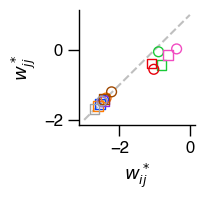

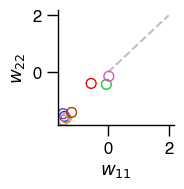

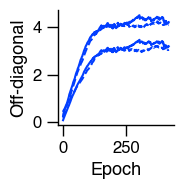

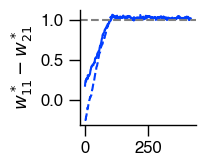

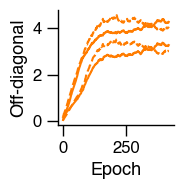

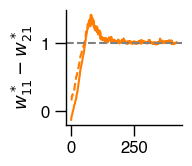

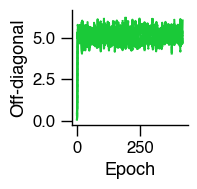

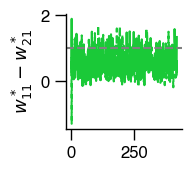

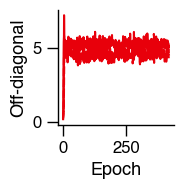

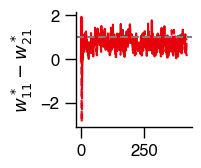

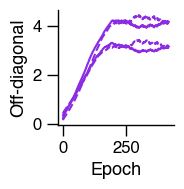

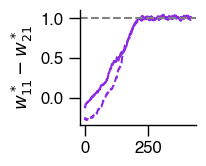

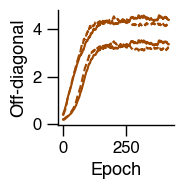

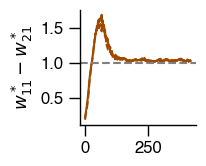

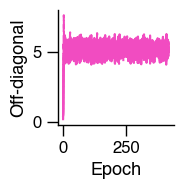

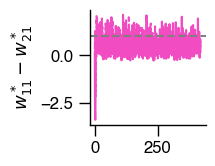

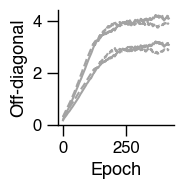

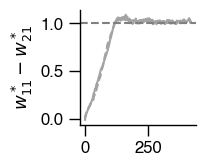

In [96]:
plot_all_weight_stats(DATA_PATHS_NO_HET_SHORT)

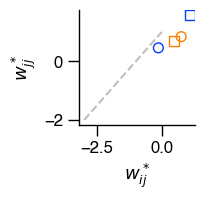

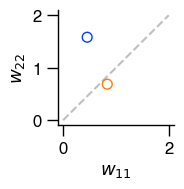

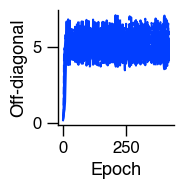

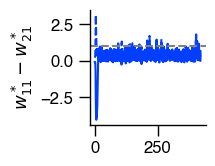

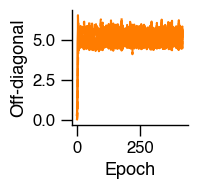

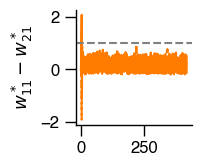

In [53]:
plot_all_weight_stats(DATA_PATHS_NO_HET_LONG)

(420, 7, 7)
(420, 7, 7)
(420, 7, 7)


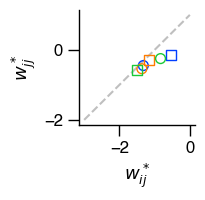

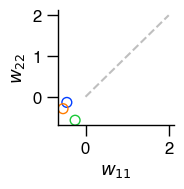

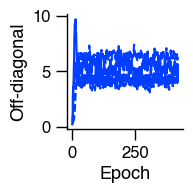

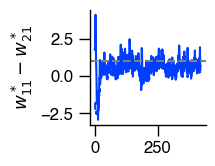

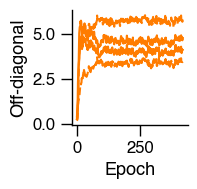

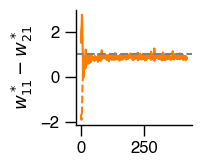

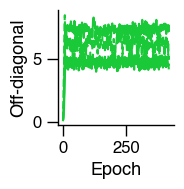

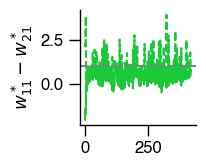

In [97]:
plot_all_weight_stats(DATA_PATHS_HET_SHORT)

(420, 7, 7)


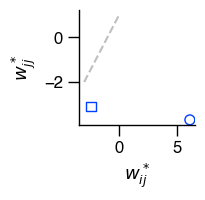

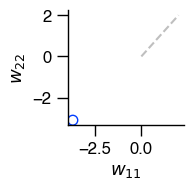

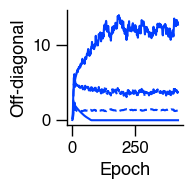

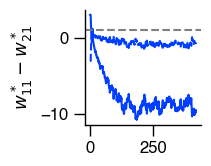

In [98]:
plot_all_weight_stats(DATA_PATHS_HET_LONG)

### Epoch over epoch weight change

In [10]:
def graph_epoch_over_epoch_weight_change(dps, k=5, save_name=None, combined=False):
    if combined:
        fig, axs = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(3, 1))
        axs = np.atleast_1d(axs)
    else:
        fig, axs = plt.subplots(len(dps), 1, sharex=True, sharey=True, figsize=(3, len(dps) * 1))
    for i, dp in enumerate(dps):
        all_w = load_numpy(os.path.join(dp, f'weights/net_00{k}.npy')).squeeze()
        all_w_trimmed = all_w[:, :CELL_TYPE_1_SIZE, :CELL_TYPE_1_SIZE]
        diffs = np.linalg.norm(all_w_trimmed[1:, ...] - all_w_trimmed[:-1, ...], axis=(1, 2))
        denoms = np.linalg.norm(all_w_trimmed[:-1, ...], axis=(1, 2))
        normed_diffs = diffs / denoms
        index = i if not combined else 0
        axs[index].plot(np.arange(len(normed_diffs)), normed_diffs, lw=1)
    axs[0].set_ylabel(r'$\frac{\left\| \Delta W \right\| }{ \left\| W \right\| }$')
    axs[-1].set_xlabel('Epoch')
    axs[0].set_yscale('log')
    axs[0].set_xlim(0)
    axs[0].set_ylim(2e-4, 1)
    format_plot(axs)
    if save_name is not None:
        fig.savefig(save_name, bbox_inches='tight')

In [11]:
def graph_epoch_over_epoch_weight_change_v2(dps, k=5, save_name=None, combined=False):
    if combined:
        fig, axs = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(3, 1))
        axs = np.atleast_1d(axs)
    else:
        fig, axs = plt.subplots(len(dps), 1, sharex=True, sharey=True, figsize=(3, len(dps) * 1))
    for i, dp in enumerate(dps):
        all_w = load_numpy(os.path.join(dp, f'weights/net_00{k}.npy')).squeeze()
        all_w_trimmed = all_w[:, :CELL_TYPE_1_SIZE, :CELL_TYPE_1_SIZE]
        diffs = np.abs(all_w_trimmed[1:, ...] - all_w_trimmed[:-1, ...])
        denoms = np.abs(all_w_trimmed[:-1, ...])
        normed_diffs = np.mean(diffs / denoms, axis=(1, 2))
        index = i if not combined else 0
        axs[index].plot(np.arange(len(normed_diffs)), normed_diffs, lw=1)
    axs[0].set_ylabel(r'$\left\langle \frac{|\Delta W_{ij}|}{|W_{ij}|} \right\rangle $')
    axs[-1].set_xlabel('Epoch')
    axs[0].set_yscale('log')
    axs[0].set_xlim(0)
    axs[0].set_ylim(2e-4, 1)
    format_plot(axs)
    if save_name is not None:
        fig.savefig(save_name, bbox_inches='tight')

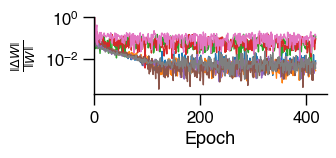

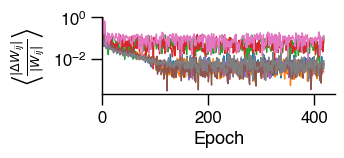

In [12]:
graph_epoch_over_epoch_weight_change(
    [os.path.join('sims_out', dp) for dp in DATA_PATHS_NO_HET_SHORT],
    save_name='./figures/2d_no_het_short_weight_change.svg',
    combined=True,
)

graph_epoch_over_epoch_weight_change_v2(
    [os.path.join('sims_out', dp) for dp in DATA_PATHS_NO_HET_SHORT],
    save_name='./figures/2d_no_het_short_weight_change_indiv.svg',
    combined=True,
)

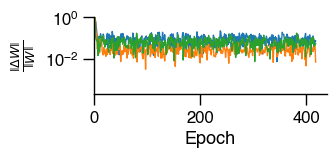

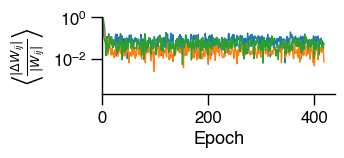

In [13]:
graph_epoch_over_epoch_weight_change(
    [os.path.join('sims_out', dp) for dp in DATA_PATHS_HET_SHORT],
    save_name='./figures/2d_het_short_weight_change.svg',
    combined=True,
)

graph_epoch_over_epoch_weight_change_v2(
    [os.path.join('sims_out', dp) for dp in DATA_PATHS_HET_SHORT],
    save_name='./figures/2d_het_short_weight_change_indiv.svg',
    combined=True,
)

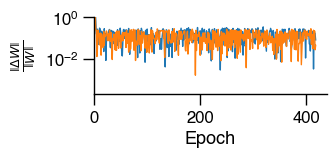

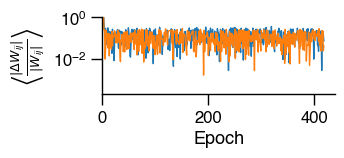

In [14]:
graph_epoch_over_epoch_weight_change(
    [os.path.join('sims_out', dp) for dp in DATA_PATHS_NO_HET_LONG],
    save_name='./figures/2d_no_het_long_weight_change.svg',
    combined=True,
)

graph_epoch_over_epoch_weight_change_v2(
    [os.path.join('sims_out', dp) for dp in DATA_PATHS_NO_HET_LONG],
    save_name='./figures/2d_no_het_long_weight_change_indiv.svg',
    combined=True,
)

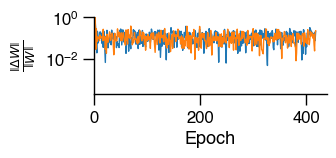

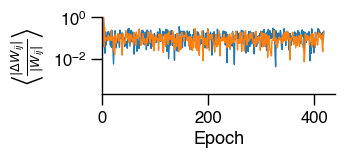

In [15]:
graph_epoch_over_epoch_weight_change(
    [os.path.join('sims_out', dp) for dp in DATA_PATHS_HET_LONG],
    save_name='./figures/2d_het_long_weight_change.svg',
    combined=True,
)

graph_epoch_over_epoch_weight_change_v2(
    [os.path.join('sims_out', dp) for dp in DATA_PATHS_HET_LONG],
    save_name='./figures/2d_het_long_weight_change_indiv.svg',
    combined=True,
)

### Analysis of neural activity

In [159]:
def plot_activity(dp, k, time_window=(None, None), save_name=None):
    last_100_r, all_int_values = load_r_and_int_values(dp, f'net_00{k}.npy', last_n=100)

    print(last_100_r.shape)
    print(all_int_values.shape)

    scale = 0.4
    fig, axs = plt.subplots(1, 1, figsize=(5 * scale, 4 * scale))
    
    max_abs_int_val = np.abs(all_int_values).max()
    
    for i in range(0, 100, 1):
    
        cbar = axs.scatter(
            last_100_r[0, i, slice(*time_window)],
            last_100_r[1, i, slice(*time_window)],
            cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True),
            s=0.01,
            c=all_int_values[i, slice(*time_window)],
            vmin=-max_abs_int_val,
            vmax=max_abs_int_val,
            rasterized=True,
        )
        if i == 0:
            cbar_ax = plt.colorbar(cbar)
            format_plot(cbar_ax.ax, leftspine=False, bottomspine=False)
            cbar_ax.ax.set_title('Decoded value')
    axs.set_xlabel(r'$x_1$')
    axs.set_ylabel(r'$x_2$')
    
    format_plot(axs)
    
    cbar_ax.outline.set_visible(False)
    # fig.savefig('./figures/encoding_manifold_250ms_no_het.svg')
    if save_name is not None:
        fig.savefig(save_name, bbox_inches='tight')
    

(2, 100, 2799)
(100, 2799)
(2, 100, 2799)
(100, 2799)
(2, 100, 2799)
(100, 2799)
(2, 100, 2799)
(100, 2799)
(2, 100, 2799)
(100, 2799)
(2, 100, 2799)
(100, 2799)
(2, 100, 2799)
(100, 2799)
(2, 100, 2799)
(100, 2799)


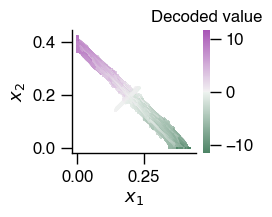

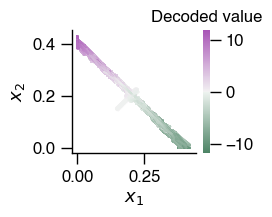

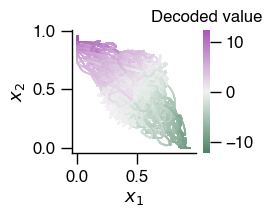

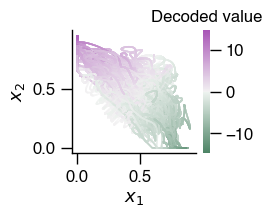

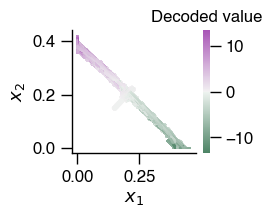

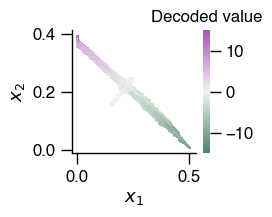

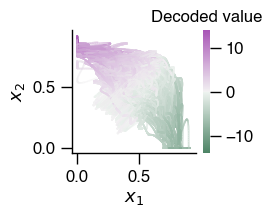

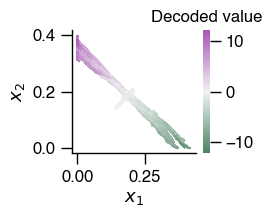

In [160]:
for i, dp in enumerate(DATA_PATHS_NO_HET_SHORT):
    plot_activity(os.path.join('sims_out', dp), 5, save_name=f'./figures/2d_no_het_short_manifold_{i}.svg')

In [161]:
# for dp in DATA_PATHS_NO_HET_SHORT:
#     plot_activity(os.path.join('sims_out', dp), 5, (int(0.27/1e-4), None))

(2, 100, 9800)
(100, 9800)
(2, 100, 9800)
(100, 9800)


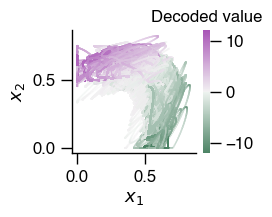

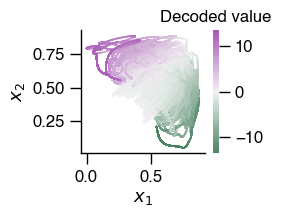

In [162]:
for i, dp in enumerate(DATA_PATHS_NO_HET_LONG):
    plot_activity(os.path.join('sims_out', dp), 5, save_name=f'./figures/2d_no_het_long_manifold_{i}.svg')

In [59]:
# for dp in DATA_PATHS_NO_HET_LONG:
#     plot_activity(os.path.join('sims_out', dp), 5, (int(0.97/1e-4), None))

(2, 100, 2799)
(100, 2799)
(2, 100, 2799)
(100, 2799)
(2, 100, 2799)
(100, 2799)


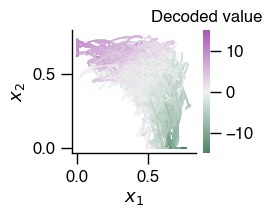

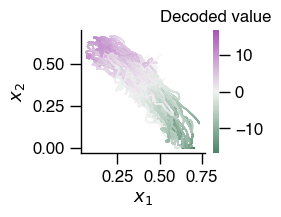

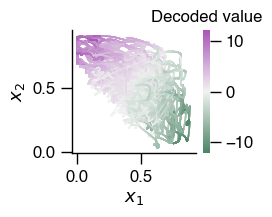

In [163]:
for i, dp in enumerate(DATA_PATHS_HET_SHORT):
    plot_activity(os.path.join('sims_out', dp), 5, save_name=f'./figures/2d_het_short_manifold_{i}.svg')

In [61]:
# for dp in DATA_PATHS_HET_SHORT:
#     plot_activity(os.path.join('sims_out', dp), 5, (int(0.27/1e-4), None))

(2, 100, 9800)
(100, 9800)


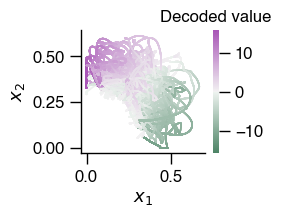

In [164]:
for i, dp in enumerate(DATA_PATHS_HET_LONG):
    plot_activity(os.path.join('sims_out', dp), 5, save_name=f'./figures/2d_het_long_manifold_{i}.svg')

In [100]:
def make_tuning_curves(last_100_r, all_int_values, save_name=None):
    ending_states = np.empty((last_100_r.shape[0], last_100_r.shape[1]))
    int_values_for_ending_states = np.empty((all_int_values.shape[0]))
    for i, j in enumerate(np.argsort(all_int_values[:, -50])):
        ending_states[:, i] = last_100_r[:, j, -50]
        int_values_for_ending_states[i] = all_int_values[j, -50]
    
    scale = 2
    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
    m = np.abs(ending_states).max()
    axs.matshow(ending_states, cmap='bwr', vmin=-m, vmax=m, aspect=4)
    
    format_plot(axs, rightspine=True, topspine=True)
    
    axs.set_xlabel('Integrated sum')
    axs.set_xticks([0, 100], ['Leftmost', 'Rightmost'])
    axs.set_ylabel('Neuron')
    axs.set_yticks([0, CELL_TYPE_1_SIZE - 1])
    axs.tick_params(axis='both', length=6)

    if save_name is not None:
        fig.savefig(save_name + '_tuning_curve_hist.svg', bbox_inches='tight')
    
    scale = 1
    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
    
    cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)
    int_min, int_max = int_values_for_ending_states.min(), int_values_for_ending_states.max()
    colors = [cmap((int_values_for_ending_states[i] - int_min) / (int_max - int_min))[:3] for i in range(100)]  # 49 to include 0 and 1
    
    for i in range(ending_states.shape[1]):
        axs.plot(np.arange(ending_states.shape[0]), ending_states[:, i], color=colors[i], lw=1)

    norm = matplotlib.colors.Normalize(vmin=int_min, vmax=int_max)
    sm = matplotlib.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Only needed for older versions of matplotlib
    cbar = fig.colorbar(sm, ax=axs, orientation='vertical', pad=0.02)
    cbar.set_label("Integrated value")
    format_plot(cbar.ax)
    
    format_plot(axs)
    
    axs.set_ylabel('Firing rate (Hz)')
    axs.set_xlabel('Neuron')
    axs.set_xticks([0, CELL_TYPE_1_SIZE - 1], [1, CELL_TYPE_1_SIZE])
    axs.set_xlim(0, CELL_TYPE_1_SIZE - 1)
    axs.tick_params(axis='both', length=6)

    if save_name is not None:
        fig.savefig(save_name + '_firing_rates.svg', bbox_inches='tight')

In [165]:
def make_stability_plot(last_100_r, all_int_values, save_name=None):
    
    cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)
    scale = 3

    if all_int_values.shape[-1] < last_100_r.shape[-1]:
        all_int_values = np.concatenate([
            all_int_values,
            all_int_values[:,-1:] * np.ones((all_int_values.shape[0], last_100_r.shape[-1] - all_int_values.shape[-1])),
        ], axis=1)

    def normed_loc(raster):
        total_activity = raster.sum(axis=0)
        raster_normed = np.divide(
            raster,
            total_activity[None, ...],
            where=total_activity != 0,
            out=np.zeros_like(raster)
        )
        ordered_indices = np.argsort(raster, axis=0)
        max_5_indices = ordered_indices[-13:, :]
        x = np.arange(raster_normed.shape[0])
        cols = np.arange(raster.shape[1])[None, :]
        locs = np.einsum(
            'ij,ij->j',
            x[max_5_indices],
            raster_normed[max_5_indices, cols],
        )
        return locs

    all_final_traj = []

    # Create a figure with 2 columns: main plot and histogram
    fig = plt.figure(figsize=(1.3 * scale, 0.45 * scale))
    gs = gridspec.GridSpec(1, 2, width_ratios=[5, 1], wspace=0.05)
    ax_main = fig.add_subplot(gs[0])
    ax_hist = fig.add_subplot(gs[1], sharey=ax_main)

    sorted_int_values = []

    # Use global color normalization for consistent coloring
    global_max = np.max(np.abs(all_int_values))
    norm = matplotlib.colors.Normalize(vmin=-global_max, vmax=global_max)
    all_traj = []
    for i, j in enumerate(np.argsort(all_int_values[:, -1])):
        traj = normed_loc(last_100_r[:, j, :])
        all_final_traj.append(traj[-1])
        cbar = ax_main.plot(
            np.arange(all_int_values.shape[1]),
            traj,
            alpha=0.5,
            color=cmap(norm(all_int_values[j, -1])),
        )
        
        sorted_int_values.append(all_int_values[j, :])
        all_traj.append(traj)
    all_traj = np.stack(all_traj)

    

    # Main plot formatting
    ax_main.set_xlabel('Time (ms)')
    ax_main.set_ylabel('Bump location')
    ax_main.set_xticks(np.arange(0, 1301, 1000))
    ax_main.set_xticklabels((np.arange(0, 1301, 1000) / 10).astype(int))
    center_point = 0.5
    m = np.maximum(center_point - all_traj.min(), all_traj.max() - center_point)
    ax_main.set_ylim(center_point - m * 1.1, center_point + m * 1.1)
    ax_main.set_xlim(0)
    # ax_main.tick_params(axis='both', length=6, labelsize=14)
    format_plot(ax_main) #, ticklabelsize=16, axislabelsize=16)

    # Histogram on the right (rotated)
    bins = np.arange(30) / 30
    ax_hist.hist(all_final_traj, bins=bins, orientation='horizontal', color='gray')
    ax_hist.set_xlabel('Count')
    ax_hist.tick_params(axis='x')
    ax_hist.tick_params(axis='y', labelleft=False)  # Hide y-axis labels to avoid duplication
    format_plot(ax_hist)

    if save_name is not None:
        fig.savefig(save_name + '_stability_plot.svg', bbox_inches='tight')

    plt.show()

    fig, axs = plt.subplots(1, 1, figsize=(0.5 * scale, 0.5 * scale))

    # axs.plot([-m, m], [-m, m], color='black', zorder=0)
    axs.scatter(np.stack(sorted_int_values)[:, -1], all_final_traj, s=3, zorder=1, facecolor='red', edgecolor='red', alpha=0.5)
    
    axs.set_xlabel(r'$\int \left( I_{\rm R} - I_{\rm L} \right)$') #, fontsize=16)
    axs.set_ylabel('Bump location') # , fontsize=16)
    format_plot(axs)

    if save_name is not None:
        fig.savefig(save_name + '_bump_vs_value.svg', bbox_inches='tight')

In [166]:
def plot_targets_vs_predictions(dp, save_name=None):
    targets, predictions = load_targets_and_predictions(dp, f'net_00{k}.npy', last_n=100)

    scale = 3
    fig, axs = plt.subplots(1, 1, figsize=(0.5 * scale, 0.5 * scale))

    # Extract values
    t = targets[119::120]
    p = predictions[119::120]

    axs.scatter(t, p, s=3, zorder=1, facecolor='red', edgecolor='red', alpha=0.5)

    axs.set_xlabel(r'$\int \left( I_{\rm R} - I_{\rm L} \right)$')
    axs.set_ylabel('Predicted')
    format_plot(axs)

    # Compute equal axis bounds
    lo = min(t.min(), p.min())
    lo = 0.9 * lo if lo >= 0 else 1.1 * lo
    hi = max(t.max(), p.max())
    hi = 1.1 * hi if hi >= 0 else 0.9 * hi

    axs.set_xlim(lo, hi)
    axs.set_ylim(lo, hi)

    # Unity line
    axs.plot([lo, hi], [lo, hi], '--', c='grey', zorder=-1)

    # ---- Compute R^2 ----
    ss_res = np.sum((t - p) ** 2)
    ss_tot = np.sum((t - t.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    print("R^2 =", r2)

    # Optional: annotate on plot
    axs.text(0.05, 0.95, f"$R^2 = {r2:.3f}$",
             transform=axs.transAxes, va='top', ha='left')

    if save_name is not None:
        fig.savefig(save_name + '_pred_vs_value.svg', bbox_inches='tight')

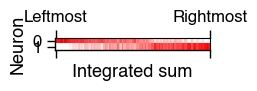

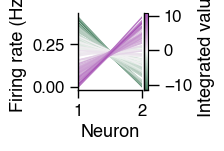

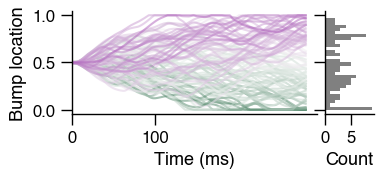

R^2 = 0.8849281891951667


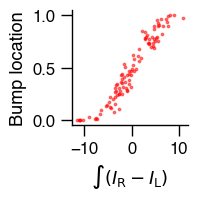

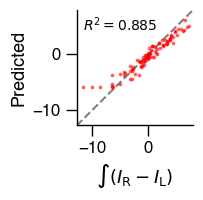

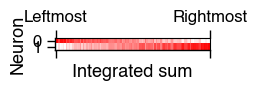

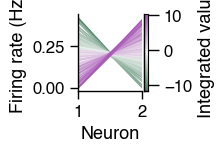

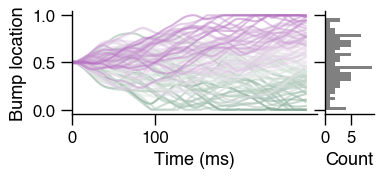

R^2 = 0.8403297985227867


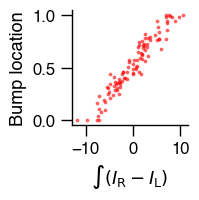

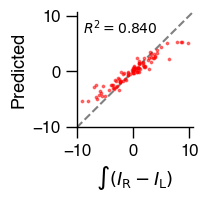

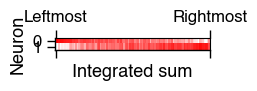

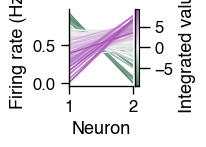

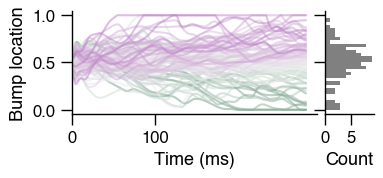

R^2 = 0.8922398159033909


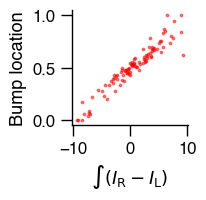

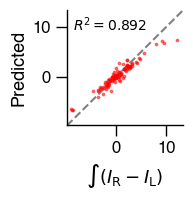

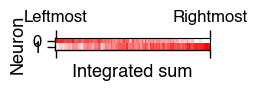

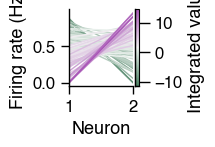

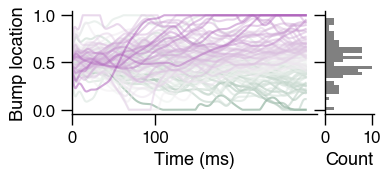

R^2 = 0.8781958526365934


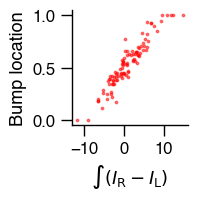

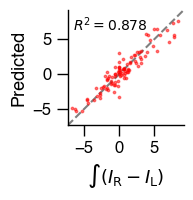

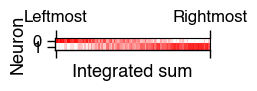

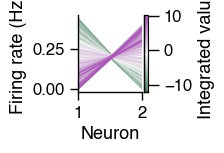

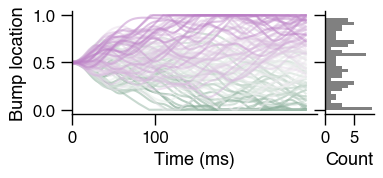

R^2 = 0.8592884458649419


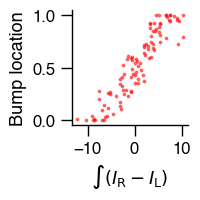

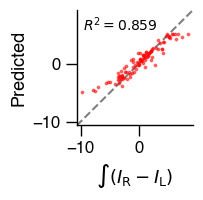

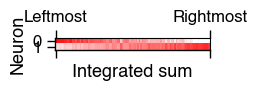

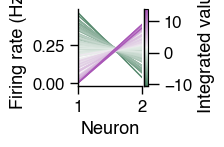

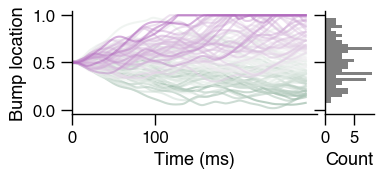

R^2 = 0.8871949238226625


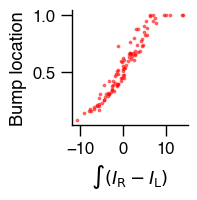

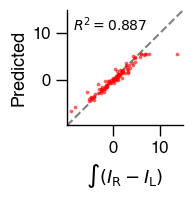

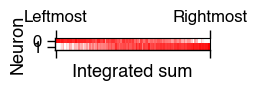

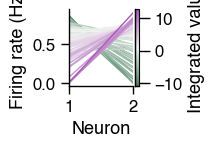

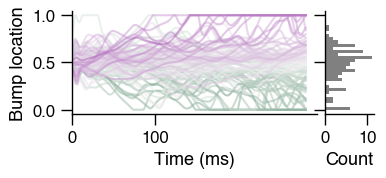

R^2 = 0.9482397949241224


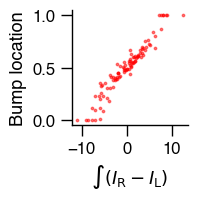

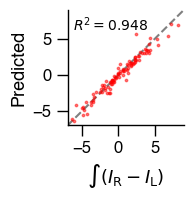

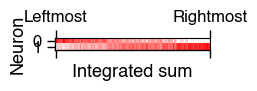

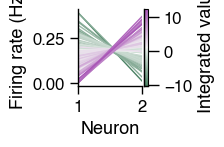

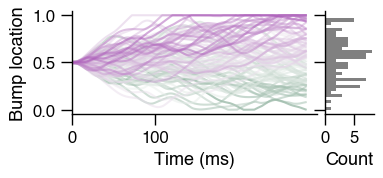

R^2 = 0.8322896646671978


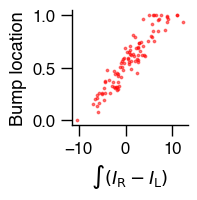

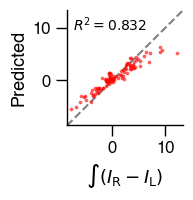

In [167]:
for i, dp in enumerate(DATA_PATHS_NO_HET_SHORT):
    dp = os.path.join('sims_out', dp)
    k = 5
    last_100_r, all_int_values = load_r_and_int_values(dp, f'net_00{k}.npy', last_n=100)
    make_tuning_curves(
        last_100_r,
        all_int_values,
        save_name=f'./figures/2d_no_het_short_{i}_index_{k}',
    )
    make_stability_plot(last_100_r, all_int_values, save_name=f'./figures/2d_no_het_short_{i}_index_{k}')
    plot_targets_vs_predictions(dp, save_name=f'./figures/2d_no_het_short_{i}_index_{k}')

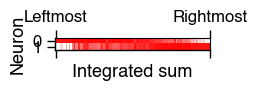

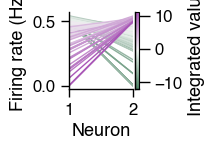

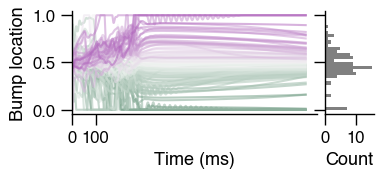

R^2 = 0.8724430208229071


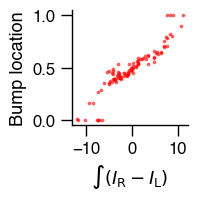

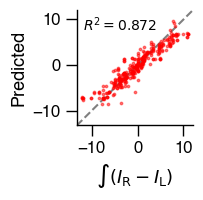

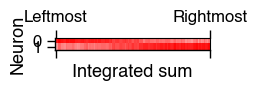

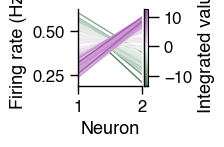

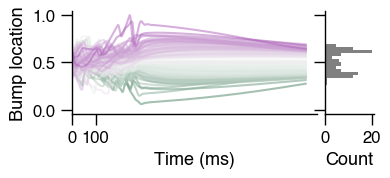

R^2 = 0.8573665840480464


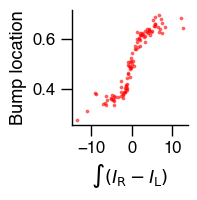

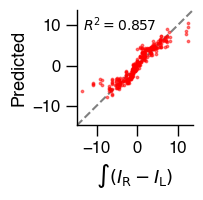

In [168]:
for i, dp in enumerate(DATA_PATHS_NO_HET_LONG):
    dp = os.path.join('sims_out', dp)
    k = 5
    last_100_r, all_int_values = load_r_and_int_values(dp, f'net_00{k}.npy', last_n=100)
    make_tuning_curves(
        last_100_r,
        all_int_values,
        save_name=f'./figures/2d_no_het_long_{i}_index_{k}',
    )
    make_stability_plot(last_100_r, all_int_values, save_name=f'./figures/2d_no_het_long_{i}_index_{k}')
    plot_targets_vs_predictions(dp, save_name=f'./figures/2d_no_het_long_{i}_index_{k}')

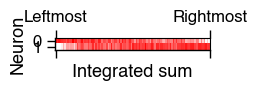

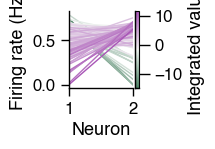

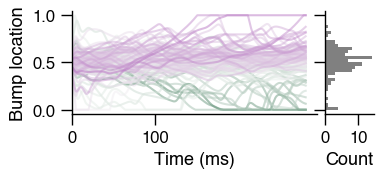

R^2 = 0.7188255237674008


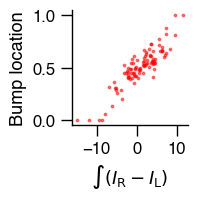

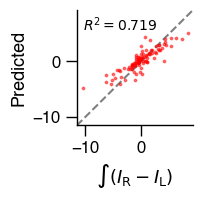

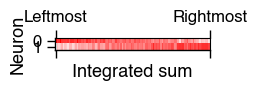

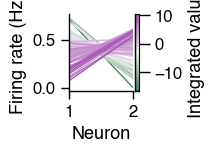

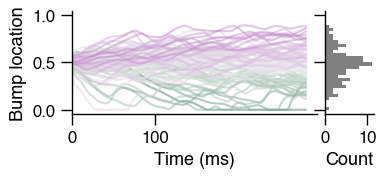

R^2 = 0.7929320153647695


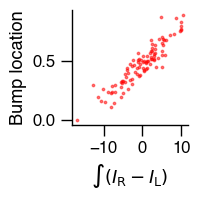

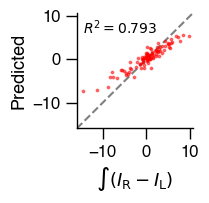

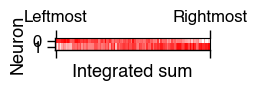

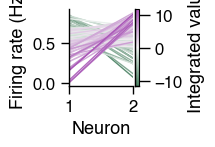

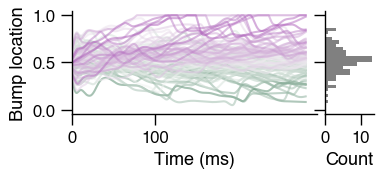

R^2 = 0.8543161278537037


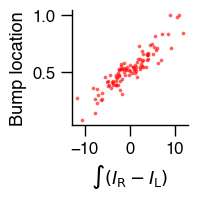

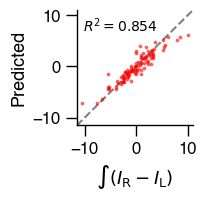

In [169]:
for i, dp in enumerate(DATA_PATHS_HET_SHORT):
    dp = os.path.join('sims_out', dp)
    k = 5
    last_100_r, all_int_values = load_r_and_int_values(dp, f'net_00{k}.npy', last_n=100)
    make_tuning_curves(
        last_100_r,
        all_int_values,
        save_name=f'./figures/2d_het_short_{i}_index_{k}',
    )
    make_stability_plot(last_100_r, all_int_values, save_name=f'./figures/2d_het_short_{i}_index_{k}')
    plot_targets_vs_predictions(dp, save_name=f'./figures/2d_het_short_{i}_index_{k}')
    
    

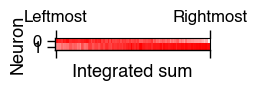

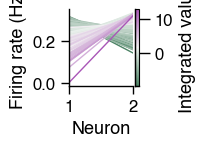

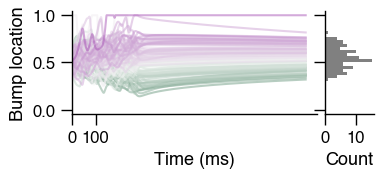

R^2 = 0.8022777365051903


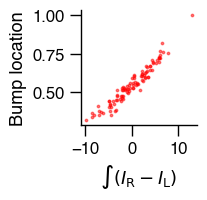

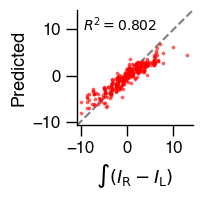

In [170]:
for i, dp in enumerate(DATA_PATHS_HET_LONG):
    dp = os.path.join('sims_out', dp)
    k = 4
    last_100_r, all_int_values = load_r_and_int_values(dp, f'net_00{k}.npy', last_n=100)
    make_tuning_curves(
        last_100_r,
        all_int_values,
        save_name=f'./figures/2d_het_long_{i}_index_{k}',
    )
    make_stability_plot(last_100_r, all_int_values, save_name=f'./figures/2d_het_long_{i}_index_{k}')
    plot_targets_vs_predictions(dp, save_name=f'./figures/2d_het_long_{i}_index_{k}')

In [17]:
def plot_all_r2(dps):
    scale = 3
    fig, axs = plt.subplots(1, 1, figsize=(0.5 * scale, 0.5 * scale))
    for dp in dps:
        dp = os.path.join('sims_out', dp)
        all_r2 = []
        for k in range(10):
            targets, predictions = load_targets_and_predictions(dp, f'net_00{k}.npy', last_n=100)
    
            # Extract values
            t = targets[119::120]
            p = predictions[119::120]
    
            ss_res = np.sum((t - p) ** 2)
            ss_tot = np.sum((t - t.mean()) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
            all_r2.append(r2)
    
        axs.plot(np.arange(10), all_r2)

    axs.set_ylim(0, 1)

    axs.set_ylabel(r'$R^2$')
    axs.set_xlabel(r'p(active)')

    axs.plot([0, 9], [0.85, 0.85], '--', alpha=0.5, zorder=-1, color='grey')
    format_plot(axs)

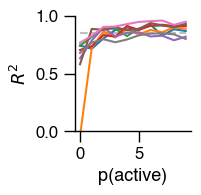

In [18]:
plot_all_r2(DATA_PATHS_NO_HET_SHORT)

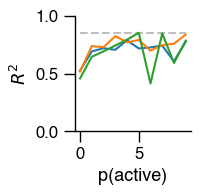

In [19]:
plot_all_r2(DATA_PATHS_HET_SHORT)

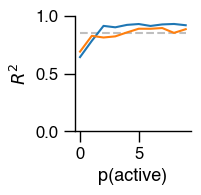

In [22]:
plot_all_r2(DATA_PATHS_NO_HET_LONG)

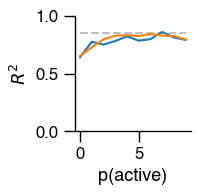

In [24]:
plot_all_r2(DATA_PATHS_HET_LONG)

In [172]:
def plot_raw_activity(dp, index, save_name=None):
    scale = 5
    last_100_r, all_int_values = load_r_and_int_values(dp, f'net_00{index}.npy', last_n=100)
    inputs_raw = load_numpy(os.path.join(dp, f'inputs/net_00{index}.npy')).squeeze(0)
    inputs = np.concatenate([np.zeros((100, 200, inputs_raw.shape[2])), inputs_raw[-100:, ...]], axis=1)
        
    for i, j in enumerate(np.argsort(all_int_values[:, -1])):
        
        if i in [0, 50, 99]:
            # Create single figure with 3 subplots
            fig, axs = plt.subplots(3, 1, figsize=(0.5 * scale, 0.35 * scale), 
                                    sharex=True,
                                    gridspec_kw={'height_ratios': [0.5, 0.5, 1]})
            
            # Top two subplots for inputs
            axs[0].matshow(inputs[j, :, :CELL_TYPE_1_SIZE].T, cmap='binary', vmin=0, vmax=30, aspect='auto')
            axs[1].matshow(inputs[j, :, CELL_TYPE_1_SIZE:].T, cmap='binary', vmin=0, vmax=30, aspect='auto')
            
            # Bottom subplot for activity trace
            m = np.abs(last_100_r[:, j, :]).max()
            axs[2].matshow(last_100_r[:, j, :], cmap='bwr', vmin=-1.1 * m, vmax=1.1 * m, aspect='auto')
            
            # Format all subplots
            for k in range(3):
                if k == 0:
                    axs[k].set_ylabel(r'$I_R$')
                elif k == 1:
                    axs[k].set_ylabel(r'$I_L$')
                else:
                    axs[k].set_ylabel('Neuron')
                    
                axs[k].set_yticks([])
                axs[k].tick_params(axis='x', bottom=True, top=False, labelbottom=True, labeltop=False)
                axs[k].xaxis.set_label_position('bottom')
            
            # X-axis formatting
            axs[0].set_xticklabels([])
            axs[1].set_xticklabels([])
            axs[2].set_xticks(np.arange(0, 2501, 2500), (np.arange(0, 2501, 2500) / 10).astype(int))
            axs[2].set_xlabel('Time (ms)')

            axs[0].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
            axs[1].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
            
            format_plot(axs, rightspine=True, topspine=True)
            plt.tight_layout()

            if save_name is not None:
                fig.savefig(save_name + f'_activition_{i}.svg', bbox_inches='tight')

2D_short_reverted_test_000850_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:56:02.567091_run_None
2D_short_reverted_test_000851_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:56:02.567095_run_None
2D_short_reverted_test_000852_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:56:02.567326_run_None
2D_short_reverted_test_000854_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:55:49.971242_run_None
2D_short_reverted_test_000855_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:56:06.935493_run_None
2D_short_reverted_test_000856_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:56:06.935488_run_Non

/tmp/ipykernel_1052699/902197596.py:11: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



2D_short_reverted_test_000858_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:55:51.915822_run_None


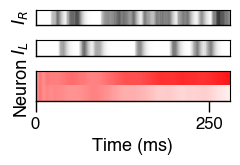

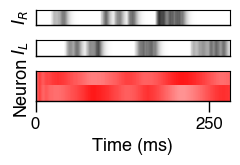

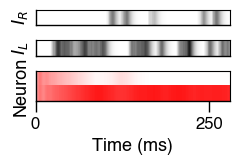

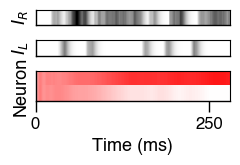

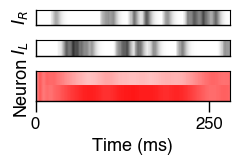

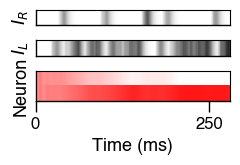

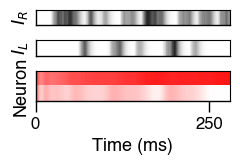

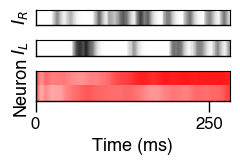

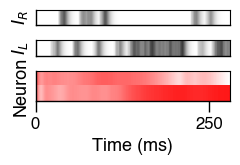

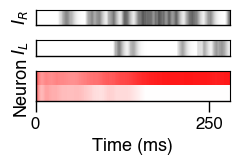

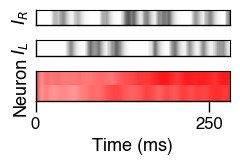

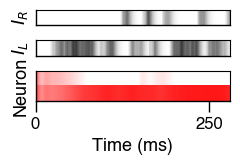

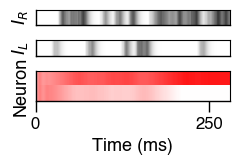

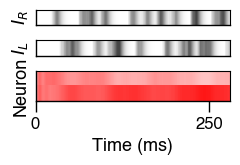

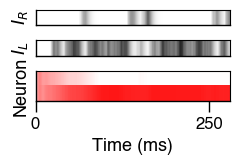

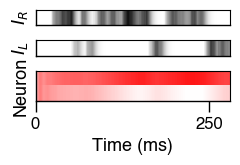

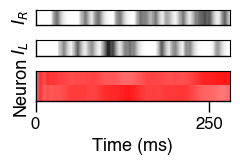

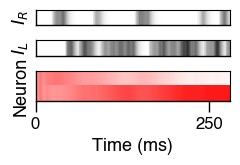

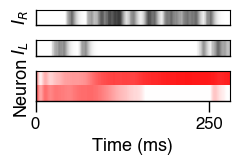

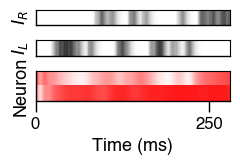

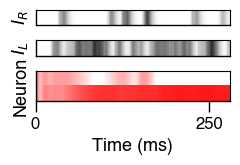

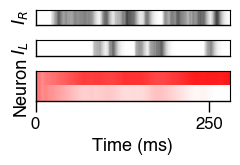

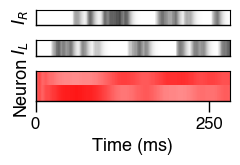

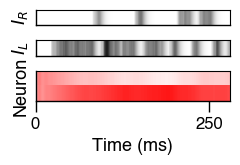

In [173]:
for i, dp in enumerate(DATA_PATHS_NO_HET_SHORT):
    print(dp)
    dp = os.path.join('sims_out', dp)
    plot_raw_activity(dp, 9, save_name=f'./figures/2d_no_het_short_activity_rule_{i}_net_{9}')

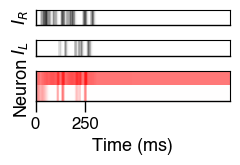

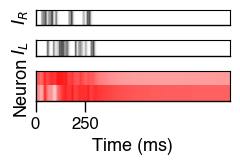

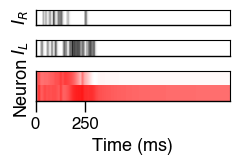

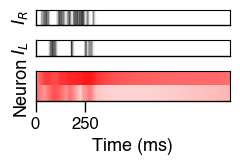

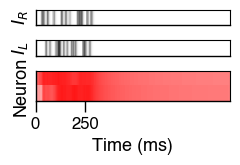

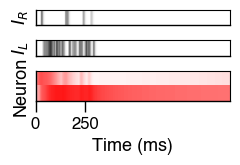

In [174]:
for i, dp in enumerate(DATA_PATHS_NO_HET_LONG):
    dp = os.path.join('sims_out', dp)
    plot_raw_activity(dp, 9, save_name=f'./figures/2d_het_short_activity_rule_{i}_net_{9}')

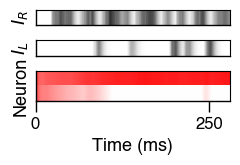

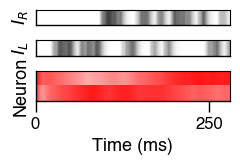

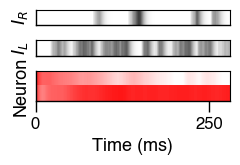

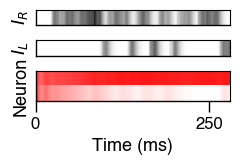

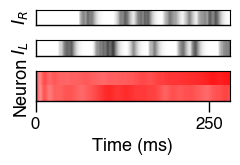

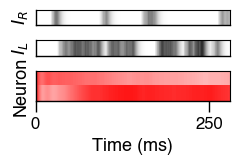

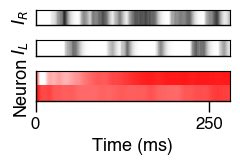

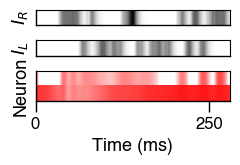

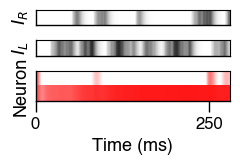

In [175]:
for i, dp in enumerate(DATA_PATHS_HET_SHORT):
    dp = os.path.join('sims_out', dp)
    plot_raw_activity(dp, 9, save_name=f'./figures/2d_het_short_activity_rule_{i}_net_{9}')

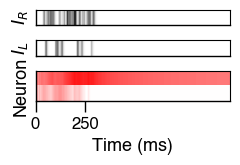

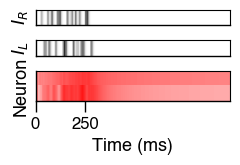

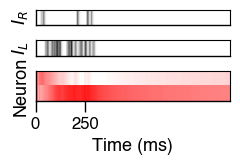

In [176]:
for i, dp in enumerate(DATA_PATHS_HET_LONG):
    dp = os.path.join('sims_out', dp)
    plot_raw_activity(dp, 8, save_name=f'./figures/2d_het_long_activity_rule_{i}_net_{8}')